<a href="https://colab.research.google.com/github/Ammar-creator-cmd/DataVisualization/blob/main/DigitRecognition1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [121]:
import tensorflow as tf
mnist = tf.keras.datasets.mnist

In [122]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train.shape

(60000, 28, 28)

In [123]:
x_train = x_train / 255.0
x_test = x_test / 255.0

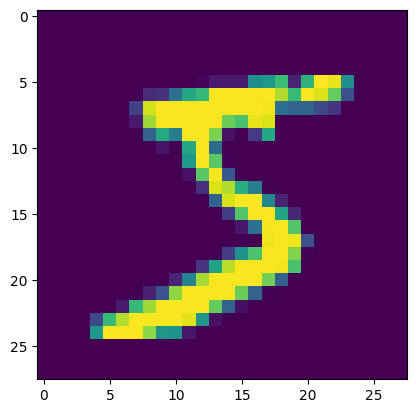

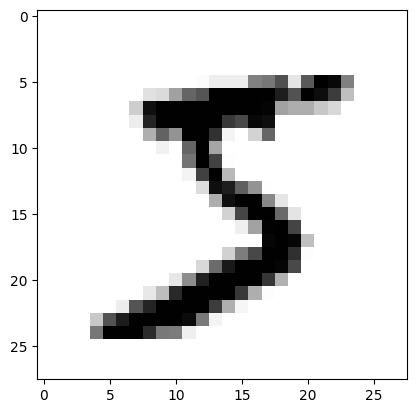

In [124]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
plt.show()
plt.imshow(x_train[0], cmap = plt.cm.binary)

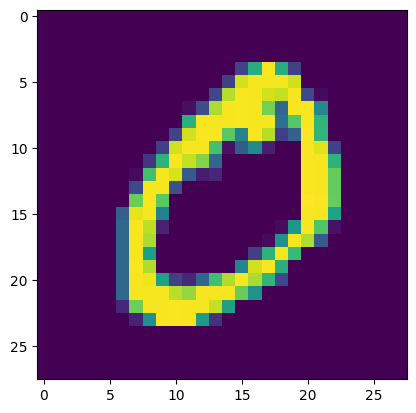

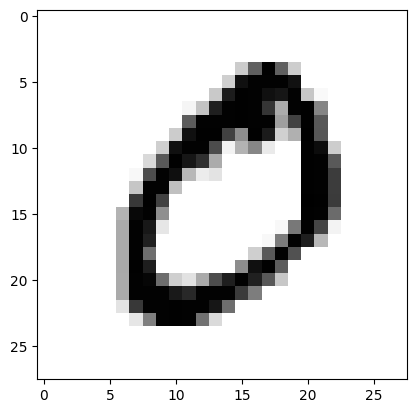

In [125]:
import matplotlib.pyplot as plt

plt.imshow(x_train[1])
plt.show()
plt.imshow(x_train[1], cmap = plt.cm.binary)

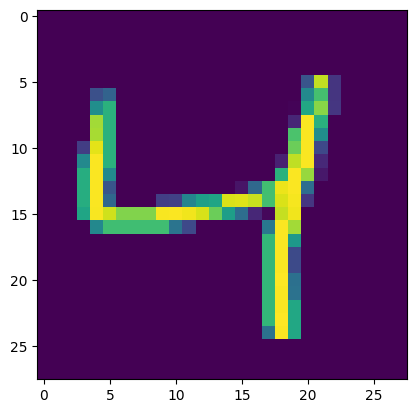

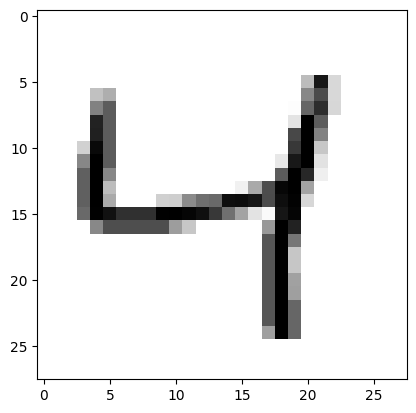

In [126]:
import matplotlib.pyplot as plt

plt.imshow(x_train[2])
plt.show()
plt.imshow(x_train[2], cmap = plt.cm.binary)

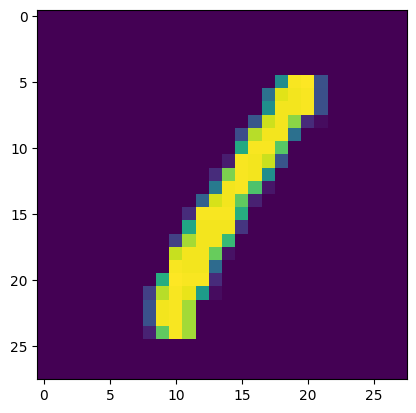

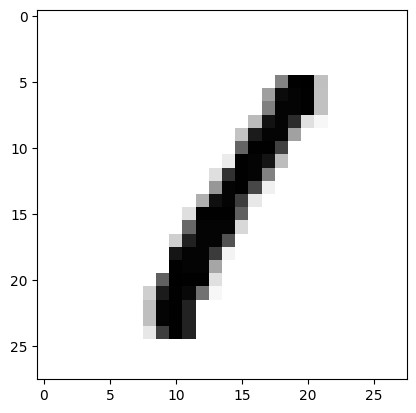

In [127]:
import matplotlib.pyplot as plt

plt.imshow(x_train[3])
plt.show()
plt.imshow(x_train[3], cmap = plt.cm.binary)

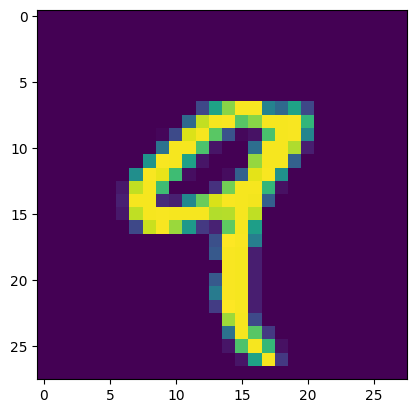

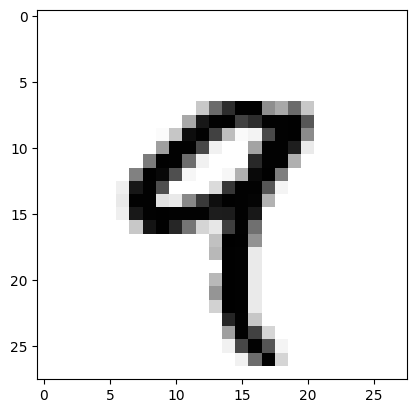

In [128]:
import matplotlib.pyplot as plt

plt.imshow(x_train[4])
plt.show()
plt.imshow(x_train[4], cmap = plt.cm.binary)

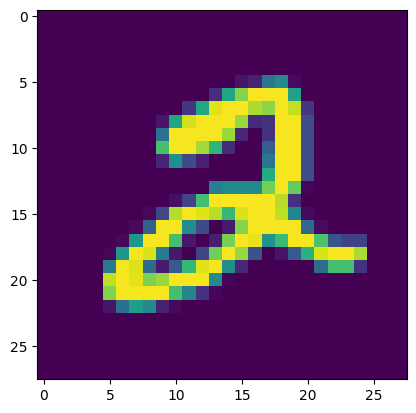

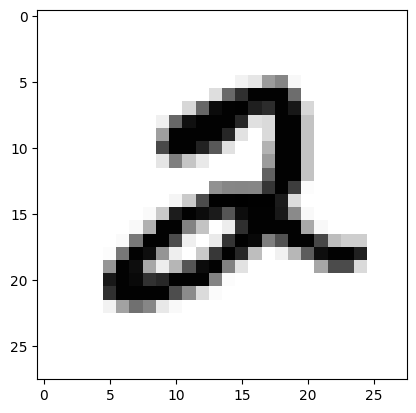

In [129]:
import matplotlib.pyplot as plt

plt.imshow(x_train[5])
plt.show()
plt.imshow(x_train[5], cmap = plt.cm.binary)

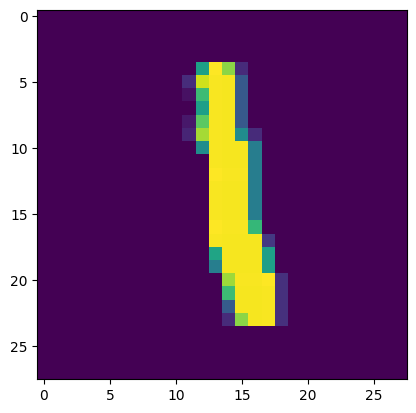

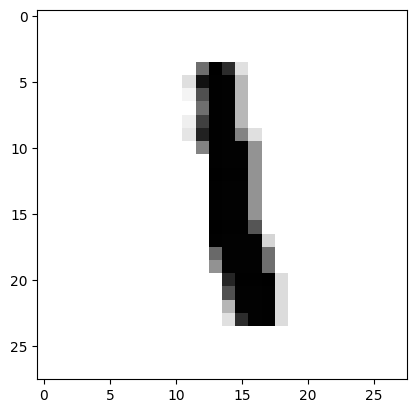

In [130]:
import matplotlib.pyplot as plt

plt.imshow(x_train[6])
plt.show()
plt.imshow(x_train[6], cmap = plt.cm.binary)

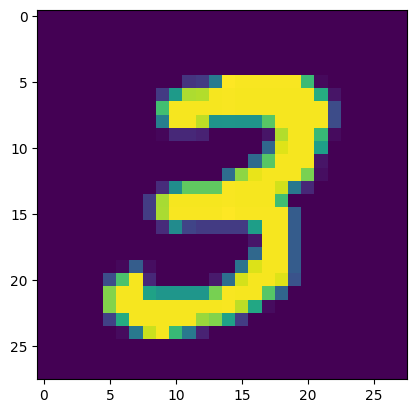

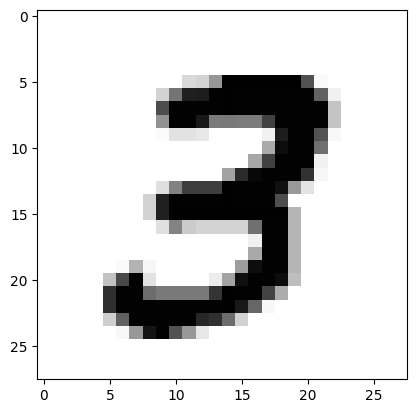

In [131]:
import matplotlib.pyplot as plt

plt.imshow(x_train[7])
plt.show()
plt.imshow(x_train[7], cmap = plt.cm.binary)

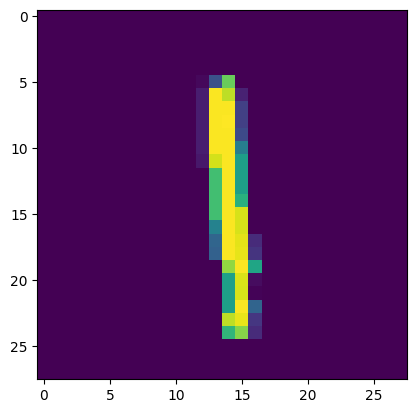

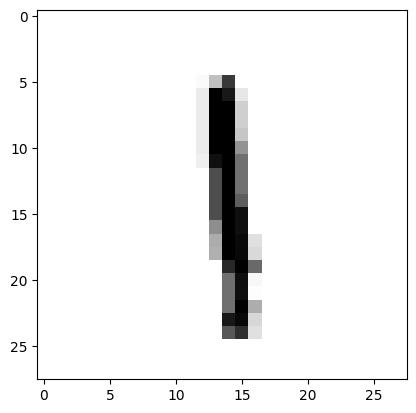

In [132]:
import matplotlib.pyplot as plt

plt.imshow(x_train[8])
plt.show()
plt.imshow(x_train[8], cmap = plt.cm.binary)

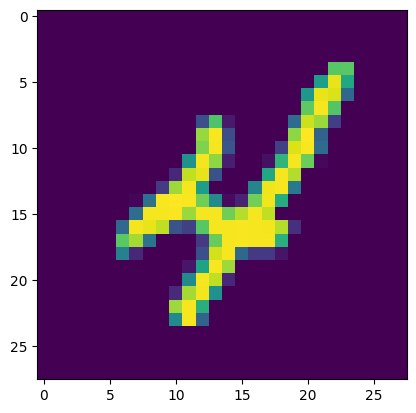

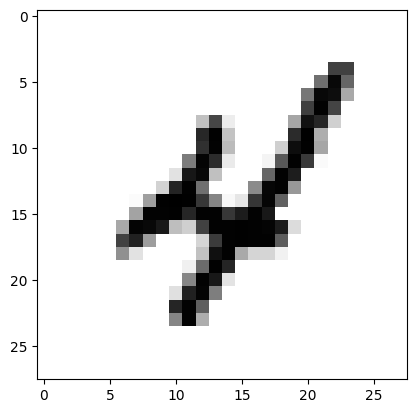

In [133]:
import matplotlib.pyplot as plt

plt.imshow(x_train[9])
plt.show()
plt.imshow(x_train[9], cmap = plt.cm.binary)

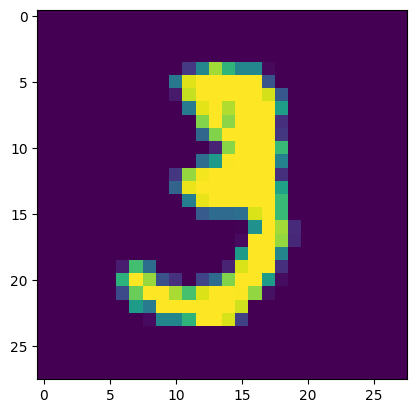

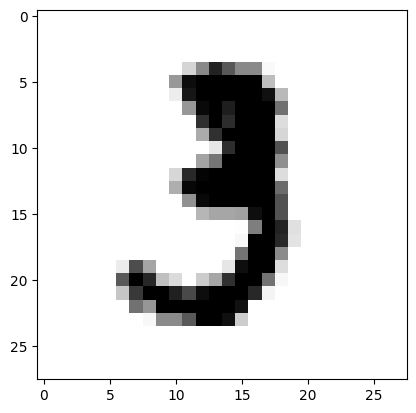

In [134]:
import matplotlib.pyplot as plt

plt.imshow(x_train[10])
plt.show()
plt.imshow(x_train[10], cmap = plt.cm.binary)

### Part 2


In [135]:
import numpy as np
img_size = 28
x_trainer = np.array(x_train).reshape(-1, img_size, img_size, 1)
x_tester = np.array(x_test).reshape(-1, img_size, img_size, 1)
print("Training shape", x_trainer.shape)
print("Testing shape", x_tester.shape)

Training shape (60000, 28, 28, 1)
Testing shape (10000, 28, 28, 1)


In [136]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

model = Sequential()

model.add(Conv2D(32, (3, 3), activation = "relu", input_shape = x_trainer.shape[1:]))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [137]:
model.add(Conv2D(64 , (3,3) , activation = 'relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(256, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation = 'softmax'))

In [138]:
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

In [139]:
model.fit(x_trainer,y_train, epochs = 8, validation_split = 0.3 , batch_size = 128,verbose=1)

Epoch 1/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 144s 432ms/step - accuracy: 0.9291 - loss: 0.2305 - val_accuracy: 0.9808 - val_loss: 0.0651
Epoch 2/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 146s 444ms/step - accuracy: 0.9760 - loss: 0.0773 - val_accuracy: 0.9852 - val_loss: 0.0504
Epoch 3/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 147s 446ms/step - accuracy: 0.9830 - loss: 0.0537 - val_accuracy: 0.9854 - val_loss: 0.0500
Epoch 4/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 146s 444ms/step - accuracy: 0.9867 - loss: 0.0430 - val_accuracy: 0.9857 - val_loss: 0.0486
Epoch 5/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 147s 446ms/step - accuracy: 0.9888 - loss: 0.0344 - val_accuracy: 0.9890 - val_loss: 0.0393
Epoch 6/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 139s 422ms/step - accuracy: 0.9888 - loss: 0.0338 - val_accuracy: 0.9882 - val_loss: 0.0408
Epoch 7/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 147s 447ms/step - accuracy: 0.9918 - loss: 0.0243 - val_accuracy: 0.9896 - val_loss: 0.0382
Epoch 8/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 141s 427ms/step - accuracy: 0.9931 - loss: 0

### Task 3

In [140]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_custom_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Error: Could not load image from {image_path}. Please ensure the file exists and the path is correct.")
        return

    img_resized = cv2.resize(img, (28, 28))

    img_inverted = cv2.bitwise_not(img_resized)

    img_normalized = img_inverted / 255.0

    img_input = np.reshape(img_normalized, (1, 28, 28))

    prediction = model.predict(img_input)
    predicted_digit = np.argmax(prediction)

    plt.imshow(img_inverted, cmap='gray')
    plt.title(f"Predicted Digit: {predicted_digit}")
    plt.axis('off')
    plt.show()

predict_custom_image('image_222a60.png')

Error: Could not load image from image_222a60.png. Please ensure the file exists and the path is correct.


In [141]:
from google.colab import files
uploaded1 = files.upload()
uploaded1 = files.upload()
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)


import os
print("Current files in directory:", os.listdir('.'))

Saving 4.jpg to 4 (7).jpg


Saving 3inverted.png to 3inverted (1).png


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9283 - loss: 0.2539
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9667 - loss: 0.1116
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9775 - loss: 0.0746
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9829 - loss: 0.0564
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9867 - loss: 0.0433
Current files in directory: ['.config', '3 (1).png', '4 (7).jpg', '3 (2).png', '4 (4).jpg', '4 (2).jpg', '3inverted.png', '4.jpg', '3inverted (1).png', '4 (5).jpg', 'drive', '4 (6).jpg', '4 (1).jpg', '3.png', '4 (3).jpg', 'sample_data']


In [142]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

313/313 - 1s - 3ms/step - accuracy: 0.9745 - loss: 0.0800

Test accuracy: 0.9745


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
✅ Finished 4.jpg: Model predicted 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
✅ Finished 3inverted.png: Model predicted 7


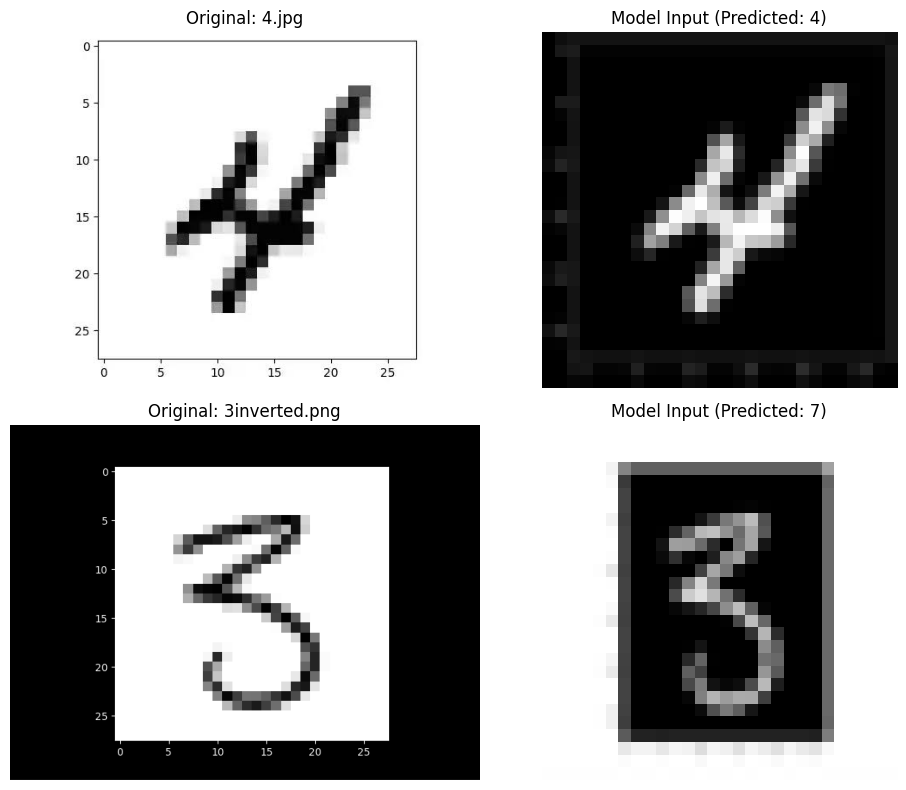

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def predict_multiple_images(image_paths, trained_model):
    num_images = len(image_paths)

    fig, axes = plt.subplots(num_images, 2, figsize=(10, 4 * num_images))

    if num_images == 1:
        axes = np.expand_dims(axes, axis=0)

    for idx, path in enumerate(image_paths):
        try:
            img_original = Image.open(path)

            img_processed = img_original.convert('L').resize((28, 28))
            img_array = np.array(img_processed) / 255.0
            img_array = 1.0 - img_array

            img_input = np.expand_dims(img_array, axis=0)
            predictions = trained_model.predict(img_input)
            predicted_digit = np.argmax(predictions)

            axes[idx, 0].imshow(img_original)
            axes[idx, 0].set_title(f"Original: {path}")
            axes[idx, 0].axis('off')

            axes[idx, 1].imshow(img_array, cmap='gray')
            axes[idx, 1].set_title(f"Model Input (Predicted: {predicted_digit})")
            axes[idx, 1].axis('off')

            print(f"✅ Finished {path}: Model predicted {predicted_digit}")

        except FileNotFoundError:
            print(f"❌ Error: Could not find the file '{path}'. Make sure it is uploaded to your environment.")

    plt.tight_layout()
    plt.show()

predict_multiple_images(['4.jpg', '3inverted.png'], model)

### Experimental with CNN

In [144]:
import tensorflow as tf

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

model_cnn = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_cnn.fit(x_train_cnn, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9547 - loss: 0.1471
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.9844 - loss: 0.0489
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9889 - loss: 0.0352
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 32ms/step - accuracy: 0.9919 - loss: 0.0258
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 30ms/step - accuracy: 0.9936 - loss: 0.0197


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
✅ Finished 4.jpg: Model predicted 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
✅ Finished 3inverted.png: Model predicted 3


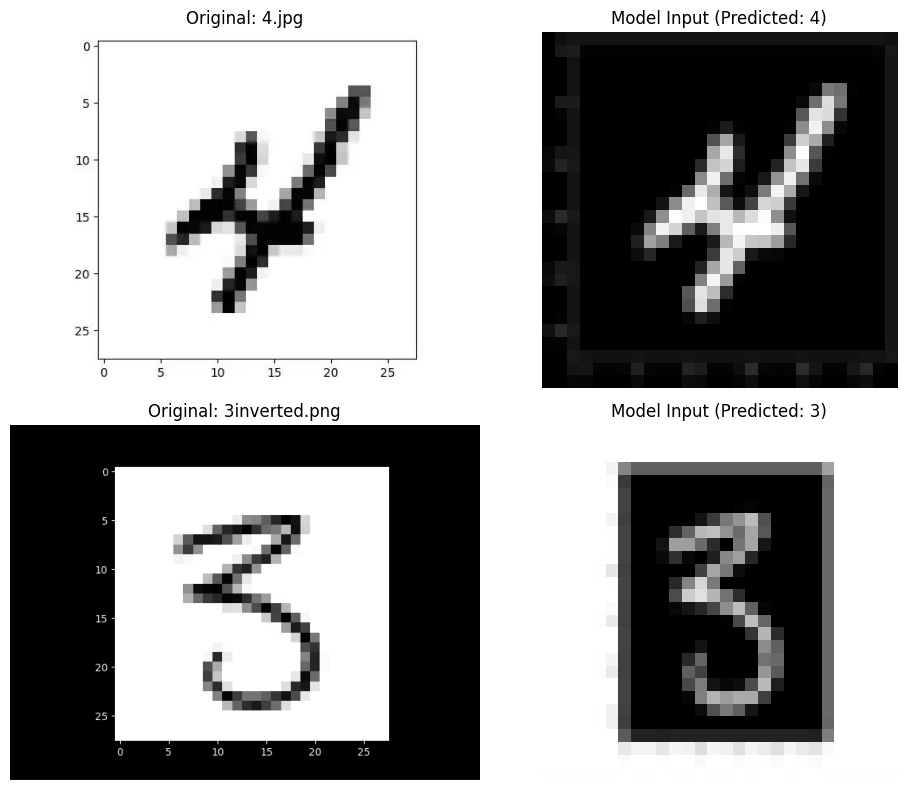

In [145]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def predict_multiple_images_optimized(image_paths, trained_model):
    num_images = len(image_paths)

    fig, axes = plt.subplots(num_images, 2, figsize=(10, 4 * num_images))

    if num_images == 1:
        axes = np.expand_dims(axes, axis=0)

    for idx, path in enumerate(image_paths):
        try:
            img_original = Image.open(path)

            img_processed = img_original.convert('L').resize((28, 28))
            img_array = np.array(img_processed) / 255.0
            img_array = 1.0 - img_array

            img_input = np.expand_dims(img_array, axis=0)
            if len(trained_model.input_shape) == 4:
                img_input = np.expand_dims(img_input, axis=-1)

            predictions = trained_model.predict(img_input)
            predicted_digit = np.argmax(predictions)

            axes[idx, 0].imshow(img_original)
            axes[idx, 0].set_title(f"Original: {path}")
            axes[idx, 0].axis('off')

            axes[idx, 1].imshow(img_array, cmap='gray')
            axes[idx, 1].set_title(f"Model Input (Predicted: {predicted_digit})")
            axes[idx, 1].axis('off')

            print(f"✅ Finished {path}: Model predicted {predicted_digit}")

        except FileNotFoundError:
            print(f"❌ Error: Could not find the file '{path}'.")

    plt.tight_layout()
    plt.show()


predict_multiple_images_optimized(['4.jpg', '3inverted.png'], model_cnn)